# Nama:RONNY RAJAGUKGUK
# NIM:4222301029
# Kelas:ROBOTIC A PAGI

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [3]:
df = pd.read_csv('berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

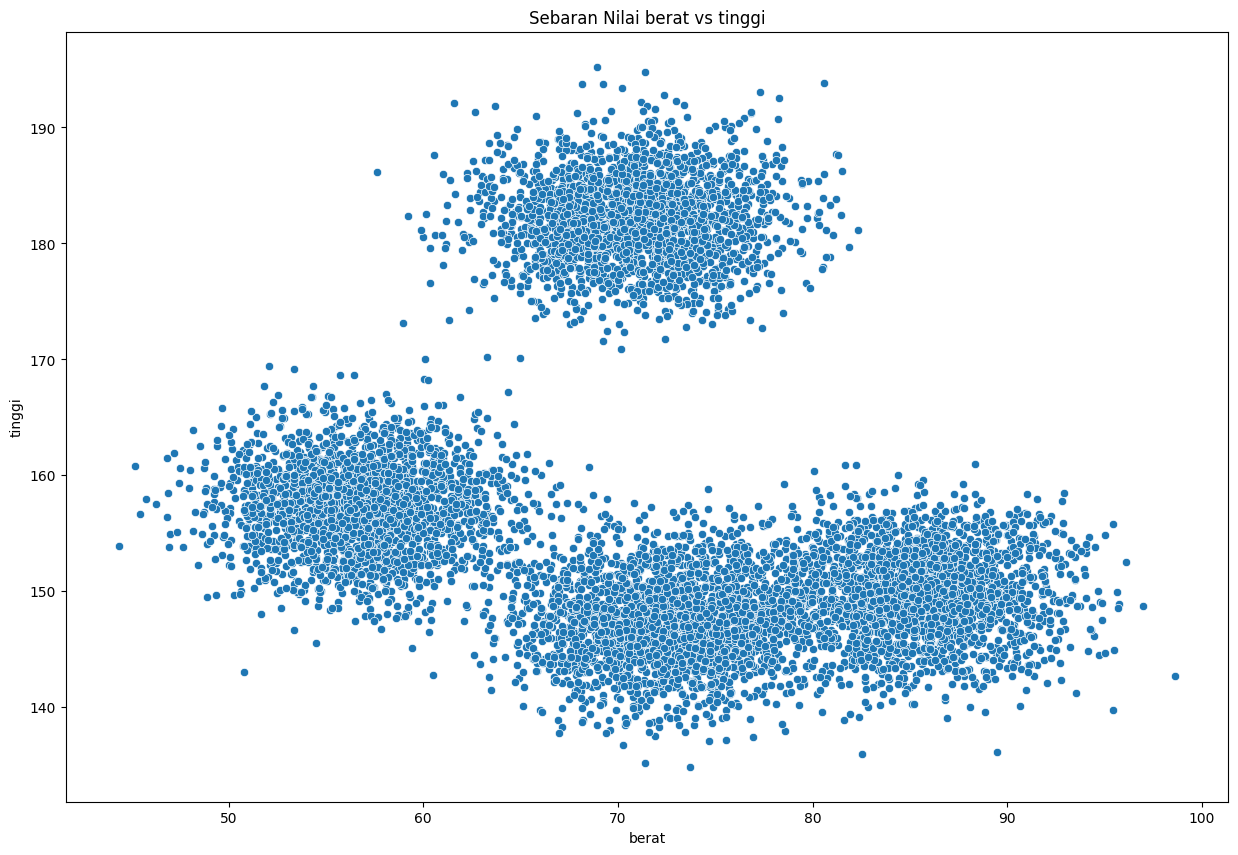

In [4]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [5]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


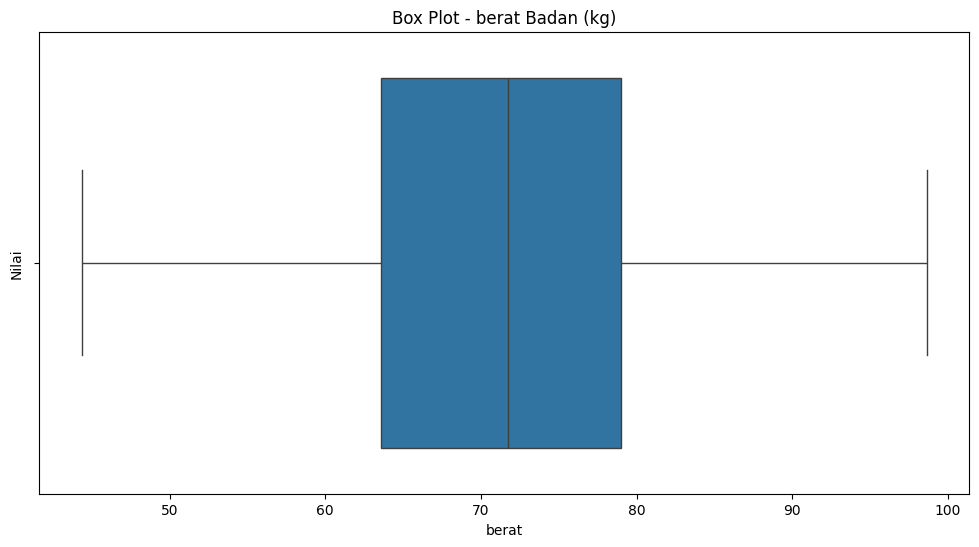

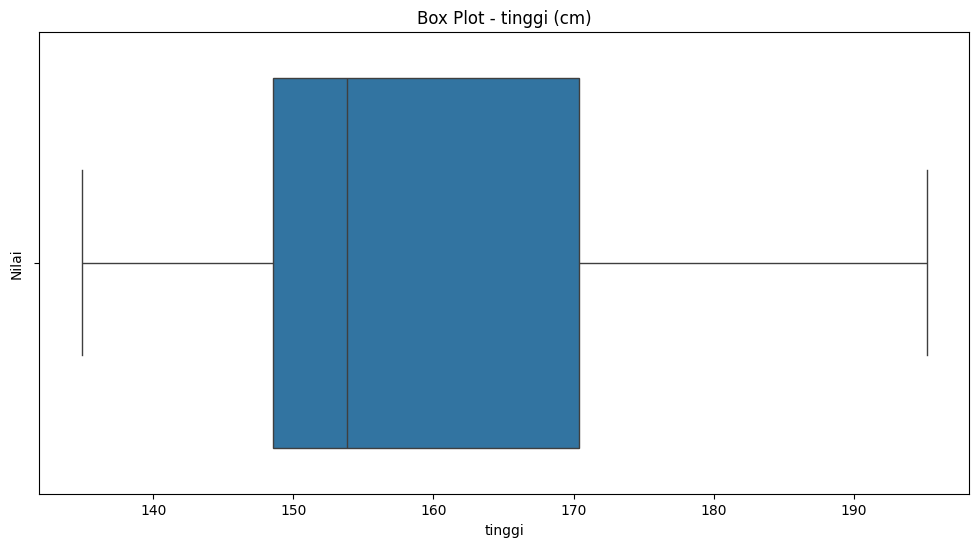

In [6]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

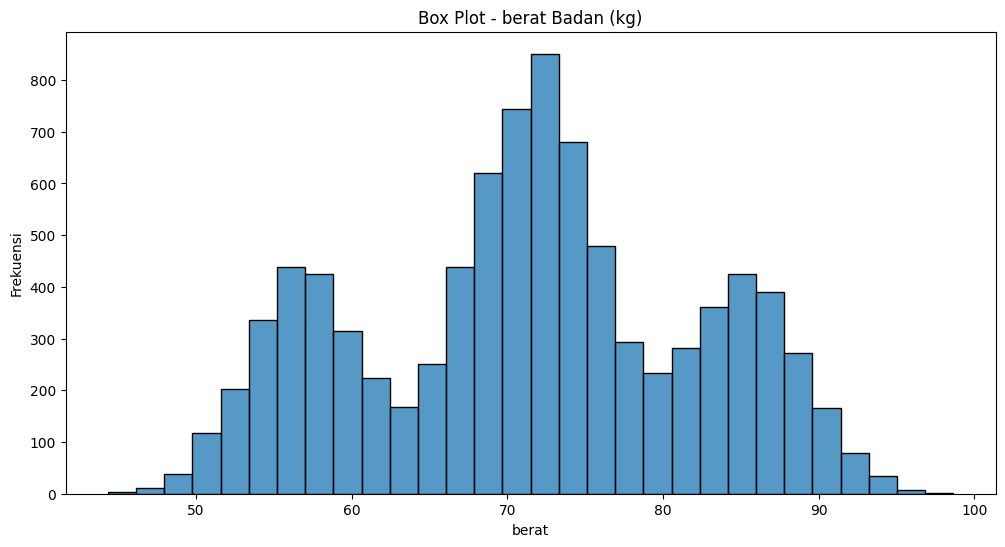

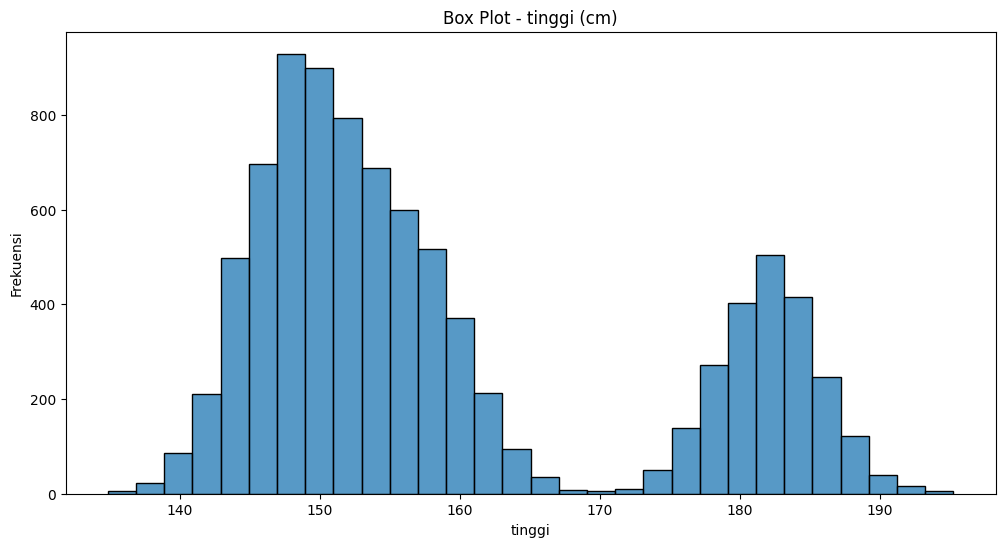

In [7]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [8]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [9]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [10]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,3.785351e-16,-1.893375e-15
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


In [11]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]])

In [12]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

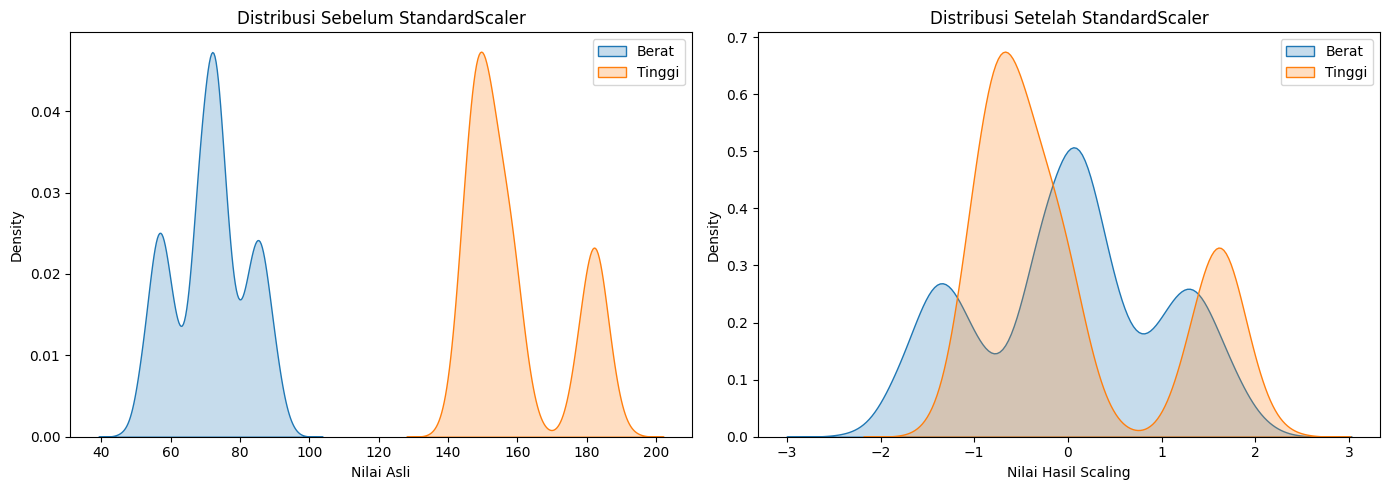

In [13]:
# cek grafik sebelum dan setelah scaling
# kita lihat distribusi dari variabel sebelum StandardScaler dan setelah StandardScaler

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14,5))

# Distribusi sebelum scaling
sns.kdeplot(df['berat'],ax=ax1,label='Berat',fill=True)
sns.kdeplot(df['tinggi'],ax=ax1,label='Tinggi',fill=True)
ax1.set_title('Distribusi Sebelum StandardScaler')

# Distribusi setelah scaling
sns.kdeplot(df_scalling['berat'],ax=ax2,label='Berat',fill=True)
sns.kdeplot(df_scalling['tinggi'],ax=ax2,label='Tinggi',fill=True)
ax2.set_title('Distribusi Setelah StandardScaler')

# Set x-label
ax1.set_xlabel('Nilai Asli')
ax2.set_xlabel('Nilai Hasil Scaling')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Sebelum dilakukan StandardScaler, data berat dan tinggi memiliki rentang nilai yang berbeda sehingga distribusinya belum seimbang. Nilai tinggi cenderung lebih besar dibanding berat sehingga dapat mempengaruhi proses analisis.

2. Setelah dilakukan feature scaling menggunakan StandardScaler, distribusi data berubah menjadi lebih terstandarisasi dengan rata-rata mendekati 0 dan standar deviasi mendekati 1.

3. Proses scaling membuat setiap fitur memiliki skala yang setara sehingga tidak ada variabel yang mendominasi variabel lain.

4. Hasil ini membantu meningkatkan performa algoritma terutama pada metode berbasis jarak seperti K-Means Clustering, KNN, dan algoritma machine learning lainnya.


## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

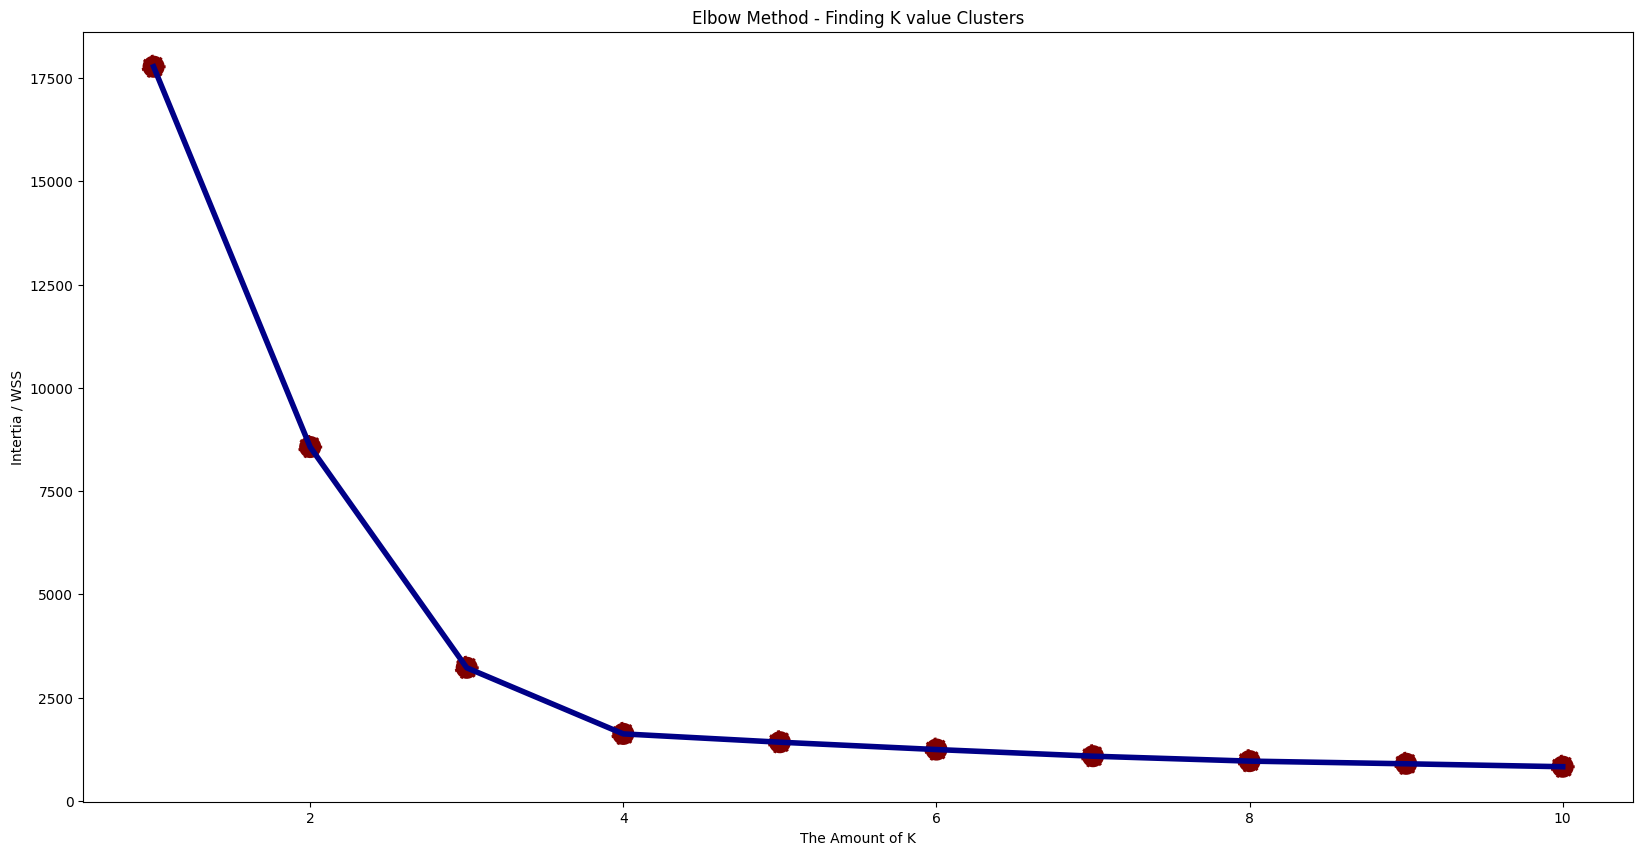

In [14]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [23]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=4, random_state=0)
kmeans_elbow.fit(df_scalling.values)

KMeans(n_clusters=4, random_state=0)

In [24]:
#taruh hasil k-means elbow method ke df dengan nama kolom cluster_elbow
df['cluster_elbow'] = kmeans_elbow.labels_

In [25]:
df

,tinggi,berat,deskripsi,cluster_elbow
0,158.114332,58.364240,Normal,2
1,160.344026,52.560155,Normal,2
2,161.486080,61.934852,Normal,2
3,182.459297,69.042108,Slim,1
4,184.462584,71.341076,Slim,1
...,...,...,...,...
8883,177.296550,74.905033,Slim,1
8884,151.605026,81.084183,Obese,3
8885,158.838120,61.779766,Normal,2
8886,156.592981,54.047666,Normal,2


<Axes: xlabel='berat', ylabel='tinggi'>

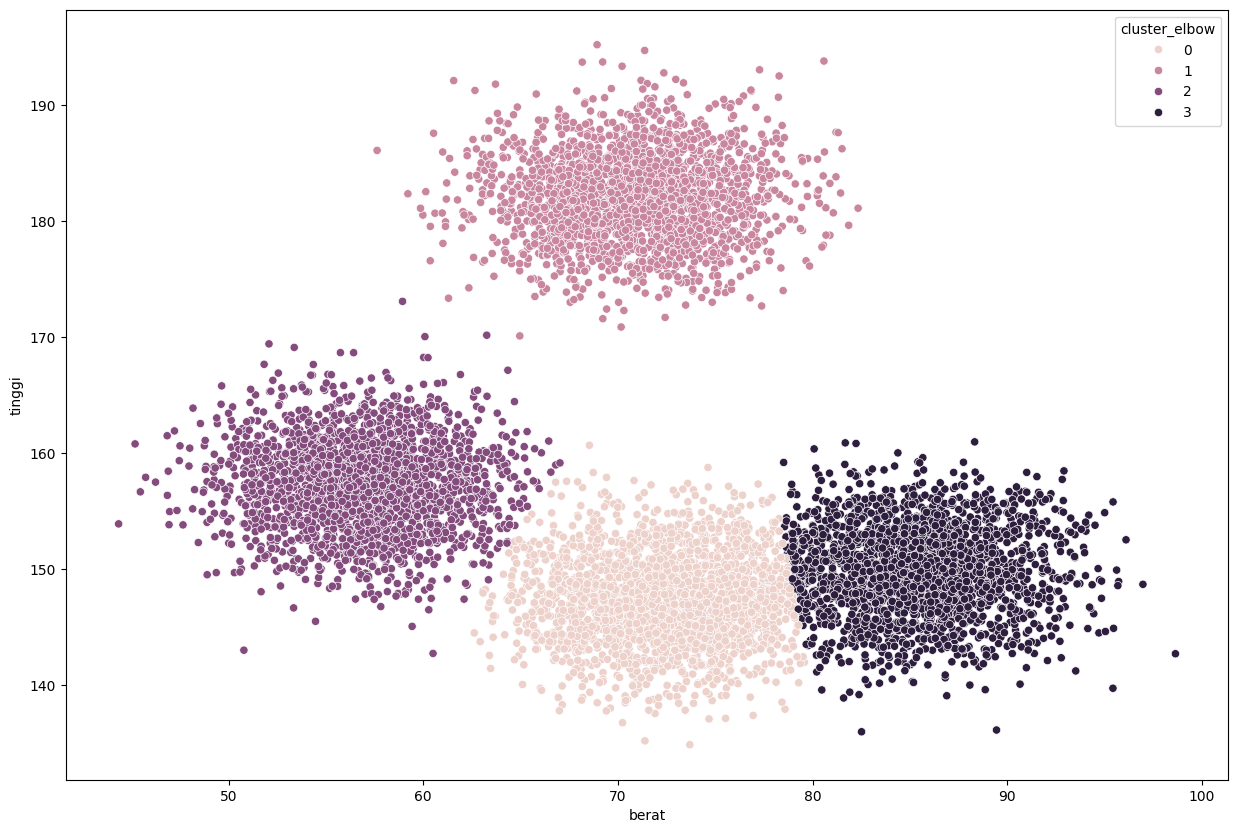

In [18]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

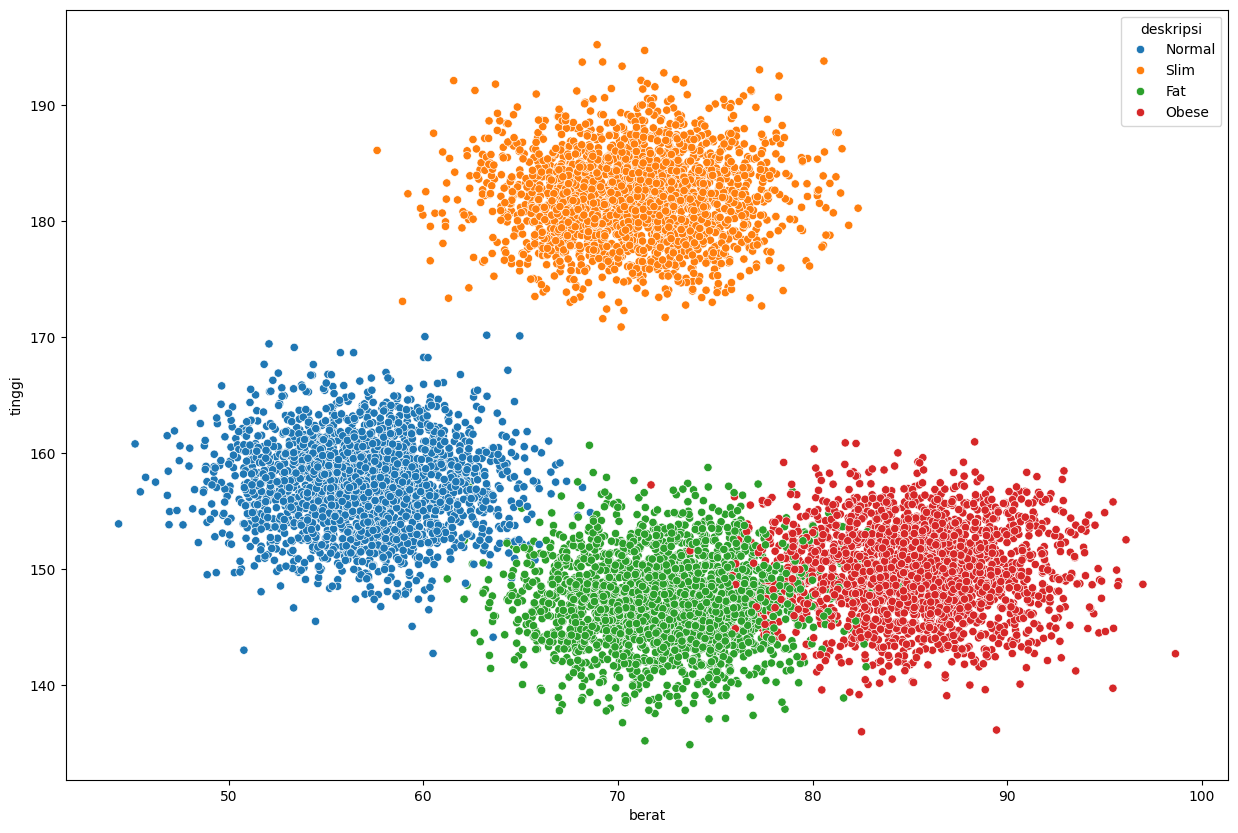

In [19]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [1]:
!pip install yellowbrick

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# baca dataset
df = pd.read_csv('berat_tinggi.csv')

# cek data
print(df.head())
print(df.shape)

       tinggi      berat deskripsi
0  158.114332  58.364240    Normal
1  160.344026  52.560155    Normal
2  161.486080  61.934852    Normal
3  182.459297  69.042108      Slim
4  184.462584  71.341076      Slim
(8888, 3)


In [6]:
# Feature Scaling ulang
from sklearn.preprocessing import StandardScaler

fitur_columns = ['berat', 'tinggi']

X = df[fitur_columns]

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# simpan hasil scaling ke dataframe
df_scalling = pd.DataFrame(
    X_std,
    columns=fitur_columns
)

df_scalling.head()

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105


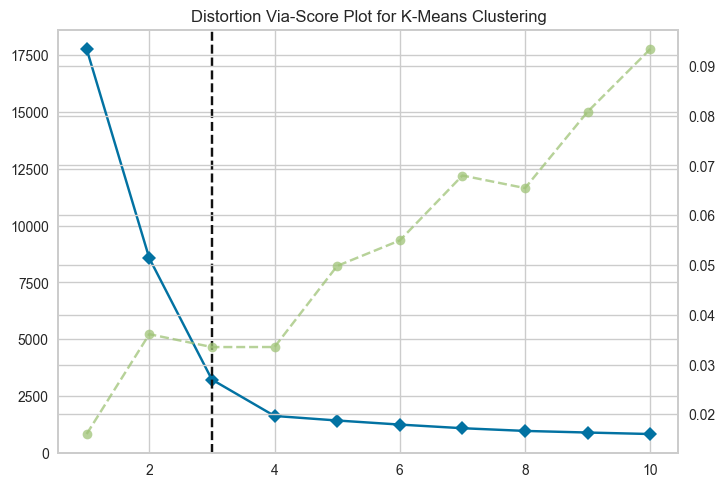

In [31]:
# Via Score Plot
from yellowbrick.cluster import KElbowVisualizer
k_means_via = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings= True)
visualizer.fit(df_scalling.values)        
# Fit the data to the visualizer
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [32]:
# Dari hasil diatas K-nya dipilih pada angka 4,
# karena titik distorsinya bertemu pada nilai 4 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

KMeans(n_clusters=3, random_state=0)

In [33]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df['cluster_via'] = kmeans_via.labels_

In [34]:
df

,tinggi,berat,deskripsi,cluster_elbow,cluster_via
0,158.114332,58.364240,Normal,2,0
1,160.344026,52.560155,Normal,2,0
2,161.486080,61.934852,Normal,2,0
3,182.459297,69.042108,Slim,1,2
4,184.462584,71.341076,Slim,1,2
...,...,...,...,...,...
8883,177.296550,74.905033,Slim,1,2
8884,151.605026,81.084183,Obese,3,1
8885,158.838120,61.779766,Normal,2,0
8886,156.592981,54.047666,Normal,2,0


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

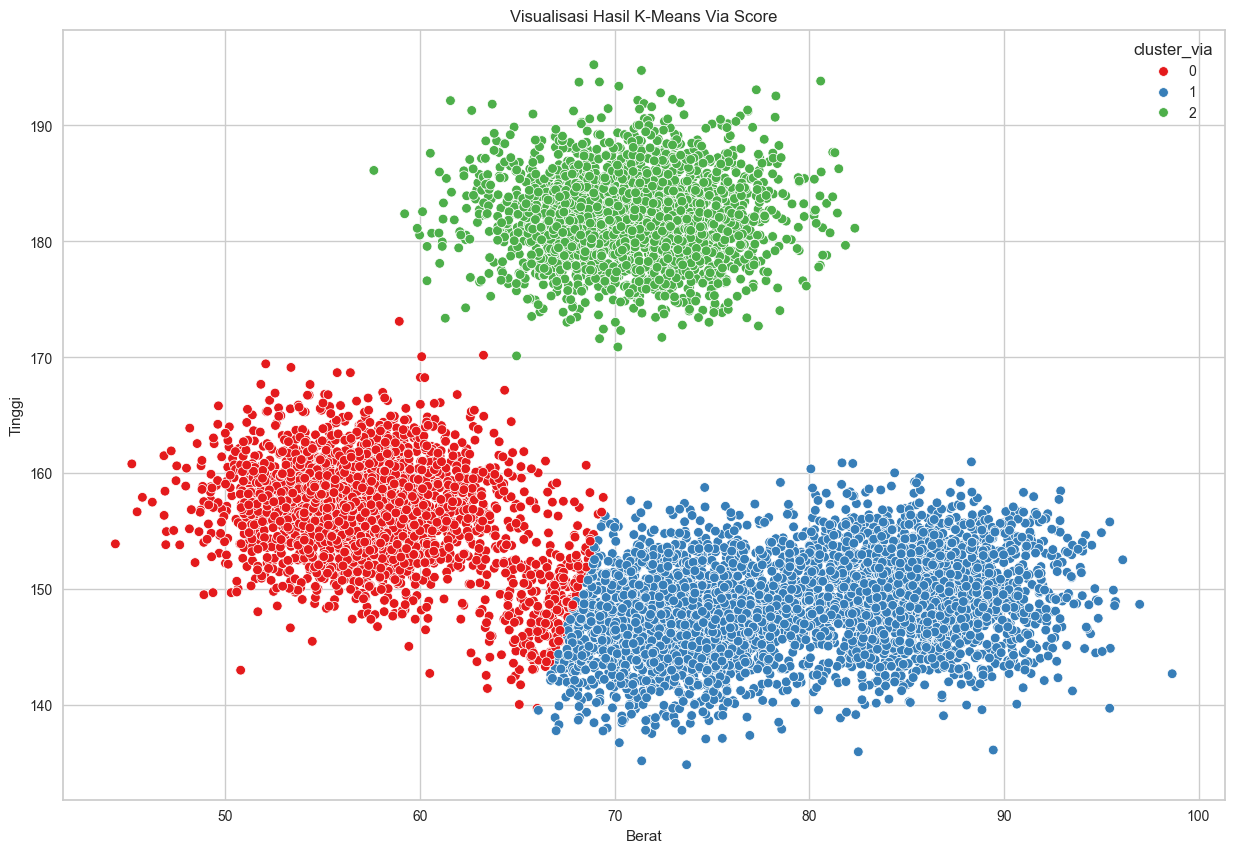

In [35]:
# Evaluasi hasil clustering
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='cluster_via',
    palette='Set1'
)

plt.title('Visualisasi Hasil K-Means Via Score')
plt.xlabel('Berat')
plt.ylabel('Tinggi')
plt.show()

### Bandingkan dengan label anotator

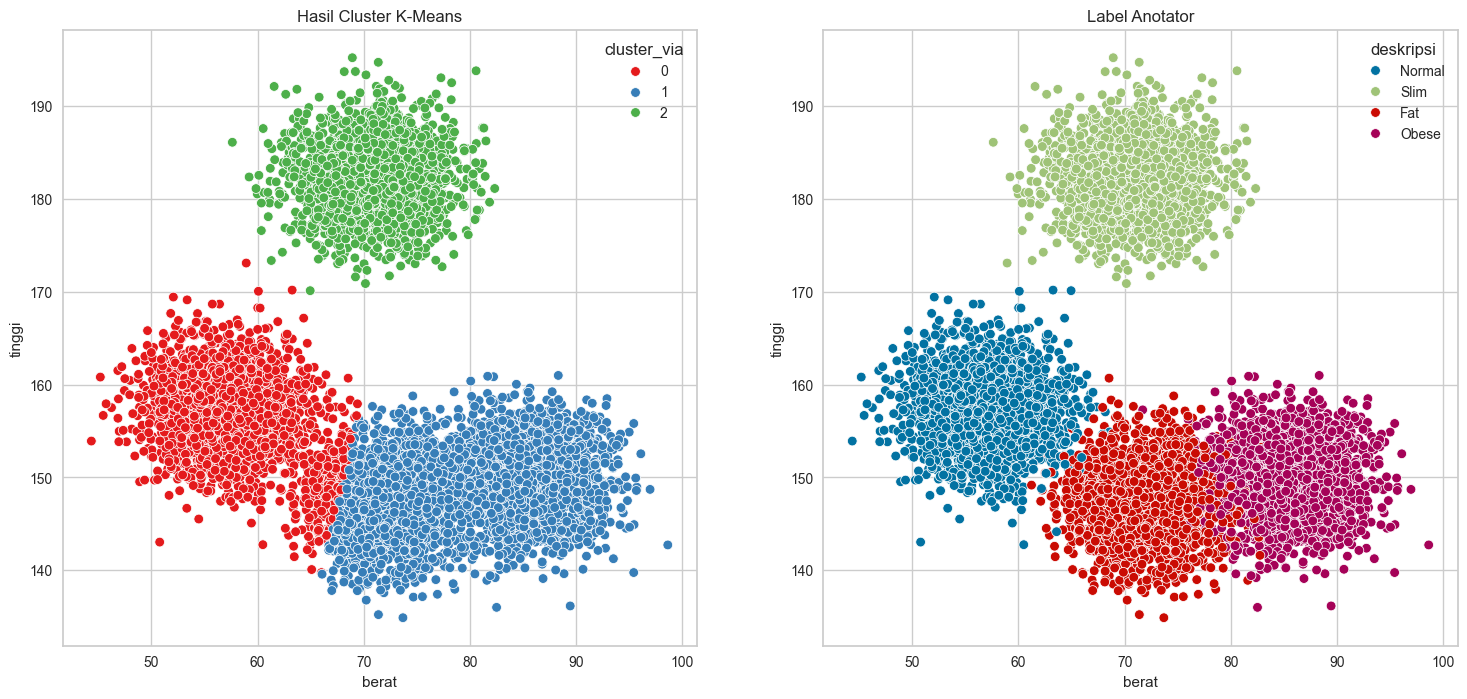

In [36]:
# Membandingkan hasil cluster dengan label anotator

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(18,8))

# Hasil clustering K-Means
sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='cluster_via',
    palette='Set1',
    ax=ax1
)

ax1.set_title('Hasil Cluster K-Means')


# Label asli anotator
sns.scatterplot(
    data=df,
    x='berat',
    y='tinggi',
    hue='deskripsi',
    ax=ax2
)

ax2.set_title('Label Anotator')

plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Hasil K-Means dengan K = 3 berhasil mengelompokkan data berdasarkan kemiripan nilai berat dan tinggi, sehingga data dengan karakteristik serupa berada pada cluster yang sama.

2. Jika dibandingkan dengan label anotator (deskripsi), hasil clustering menunjukkan pola yang cukup mirip, meskipun terdapat beberapa perbedaan karena K-Means melakukan pengelompokan berdasarkan perhitungan jarak antar data, sedangkan anotator dapat menggunakan pertimbangan tambahan dalam pelabelan data.

### Thank you :)